# Multi-Modal Neural Network for Construction Cost Prediction

This notebook builds a model combining:
- Tabular data (MLP)
- Sentinel-2 imagery (CNN)
- VIIRS imagery (CNN)

We fuse all modalities into a final regression model.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import datetime
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## Dataset handling
Loading and preparing dataset for the model

### Loading Data

In [3]:
DataPath = Path("..") / "Processed data"
ImgPath = DataPath / "processed_composite"
ModelPath = Path("..") / "Models"

#Loading all images into a dict to avoid loading them multiple times during training
img_dict = {}
for img_file in ImgPath.glob("*.pt"):
    img_dict[img_file.name] = torch.load(img_file)

full_df = pd.read_csv(DataPath / "processed_data.csv")
print(f"Full shape: {full_df.shape}")

japan_df = pd.read_csv(DataPath / "processed_japan.csv")
print(f"Japan shape: {japan_df.shape}")

philippines_df = pd.read_csv(DataPath / "processed_philippines.csv")
print(f"Philippines shape: {philippines_df.shape}")

full_df.head()

Full shape: (1024, 21)
Japan shape: (567, 18)
Philippines shape: (457, 20)


,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,landlocked,region_economic_classification,access_to_airport,access_to_port,...,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd
0,0,3,0,2019,2.996821e+11,117.689915,0,1,0,1,...,0,770.0,2,1,3,0,0,sentinel_2_dinagat_islands_2019-Q3.tif,viirs_dinagat_islands_2019-Q3.tif,129.997420
1,1,2,1,2024,3.928801e+12,143.968241,1,3,0,0,...,1,370.0,2,1,1,0,3,sentinel_2_29000_nara_2024-Q2.tif,viirs_29000_nara_2024-Q2.tif,1567.878774
2,2,1,1,2020,4.069008e+12,118.435291,0,3,1,1,...,1,450.0,2,1,1,0,5,sentinel_2_05000_akita_2020-Q1.tif,viirs_05000_akita_2020-Q1.tif,2009.827701
3,3,4,0,2020,2.912443e+11,119.402476,1,1,1,0,...,0,870.0,3,1,2,0,0,sentinel_2_cotabato_2020-Q4.tif,viirs_cotabato_2020-Q4.tif,377.279961
4,4,3,0,2019,2.996821e+11,117.689915,1,1,1,0,...,1,65.0,2,1,2,0,1,sentinel_2_pampanga_2019-Q3.tif,viirs_pampanga_2019-Q3.tif,163.905688


### Dataset class
For easier access of the data for the models

In [4]:
class MultiModalDataset(Dataset):
    def __init__(self, df, numeric_cols, categorical_cols,
                 imgs_col, target_col):
        self.df = df.reset_index(drop=True)
        numeric_cols = [col for col in numeric_cols if col in df.columns]
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.imgs_col = imgs_col
        self.target_col = target_col
        
    def __len__(self):
        return len(self.df)
    
    def load_imgs(self, path):
        return img_dict.get(path)

    def __getitem__(self, idx):

        x_num = torch.tensor(
            self.df.loc[idx, self.numeric_cols].values.astype("float32"),
            dtype=torch.float32
        )

        x_cat = torch.tensor(
            self.df.loc[idx, self.categorical_cols].values.astype("int64"),
            dtype=torch.long
        )

        imgs = self.load_imgs(self.df.loc[idx, self.imgs_col])
        img_s = imgs['sentinel']
        img_v = imgs['viirs']

        y = torch.tensor(
            float(self.df.loc[idx, self.target_col]),
            dtype=torch.float32
        )

        return {
            "numeric": x_num,
            "categorical": x_cat,
            "sentinel_img": img_s,
            "viirs_img": img_v,
            "target": y
        }

### Possible columns in the data

In [5]:
numeric_cols = [
    'deflated_gdp_usd', 'us_cpi', 'straight_distance_to_capital_km',
    'access_to_airport', 'access_to_highway', 'access_to_port',
    'access_to_railway', 'country', 'landlocked', 'flood_risk_class',
    'quarter_label', 'region_economic_classification',
    'seismic_hazard_zone', 'tornadoes_wind_risk',
    'tropical_cyclone_wind_risk'
]

target_col = 'construction_cost_per_m2_usd'

categorical_cols = ['geolocation_name', 'koppen_climate_zone']

imgs_col = "processed_imgs"

### Converting Data
Converting the data to make sure the model gets the correct data type.

In [6]:
#Convert the columns to the appropriate data types
def convert_dtypes(df, numeric_cols, categorical_cols):
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    return df

full_df = convert_dtypes(full_df, numeric_cols, categorical_cols)
japan_df = convert_dtypes(japan_df, numeric_cols, categorical_cols)
philippines_df = convert_dtypes(philippines_df, numeric_cols, categorical_cols)

print(full_df[numeric_cols].dtypes)
print(full_df[categorical_cols].dtypes)

deflated_gdp_usd                   float64
us_cpi                             float64
straight_distance_to_capital_km    float64
access_to_airport                    int64
access_to_highway                    int64
access_to_port                       int64
access_to_railway                    int64
country                              int64
landlocked                           int64
flood_risk_class                     int64
quarter_label                        int64
region_economic_classification       int64
seismic_hazard_zone                  int64
tornadoes_wind_risk                  int64
tropical_cyclone_wind_risk           int64
dtype: object
geolocation_name       category
koppen_climate_zone    category
dtype: object


## Model Definition

### Tabular Model (MLP with Embeddings)

In [7]:
class TabularModel(nn.Module):
    def __init__(self, num_numeric, cat_dims, emb_dims, dropout):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(cat_dim, emb_dim)
            for cat_dim, emb_dim in zip(cat_dims, emb_dims)
        ])

        emb_total_dim = sum(emb_dims)

        self.mlp = nn.Sequential(
            nn.Linear(num_numeric + emb_total_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

    def forward(self, x_numeric, x_categorical):
        emb = [emb_layer(x_categorical[:, i]) 
               for i, emb_layer in enumerate(self.embeddings)]
        emb = torch.cat(emb, dim=1)

        x = torch.cat([x_numeric, emb], dim=1)
        return self.mlp(x)

### CNN Image Encoder (ResNet Backbone)

In [8]:
class ImageEncoder(nn.Module):
    def __init__(self, in_channels=3, output_dim=128):
        super().__init__()
        self.backbone = models.resnet18(weights="IMAGENET1K_V1")
        self.backbone.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, output_dim)

    def forward(self, x):
        return self.backbone(x)

### Fusion Model

In [9]:
class FusionModel(nn.Module):
    def __init__(self, tabular_model, sentinel_model, viirs_model):
        super().__init__()

        self.tabular = tabular_model
        self.sentinel = sentinel_model
        self.viirs = viirs_model

        self.head = nn.Sequential(
            nn.Linear(64 + 128 + 128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x_num, x_cat, img_sentinel, img_viirs):
        t_feat = self.tabular(x_num, x_cat)
        s_feat = self.sentinel(img_sentinel)
        v_feat = self.viirs(img_viirs)

        x = torch.cat([t_feat, s_feat, v_feat], dim=1)
        return self.head(x)

### Loss Function

In [10]:
def RMSLELoss(preds, targets):
    preds = torch.clamp(preds, min=0)
    log_diff = torch.log1p(preds) - torch.log1p(targets)
    return torch.sqrt(torch.mean(log_diff ** 2))

## Model Initialization

In [11]:
def initialize_model(df: pd.DataFrame, ref_df: pd.DataFrame, dropout : float = 0):
    num_numeric = sum(1 for col in numeric_cols if col in df.columns)
    cat_dims = [ref_df[col].nunique() + 1 for col in categorical_cols]  # always use full dataset
    emb_dims = [min(50, (dim + 1) // 2) for dim in cat_dims]

    tabular_model = TabularModel(num_numeric, cat_dims, emb_dims, dropout)
    sentinel_model = ImageEncoder(in_channels=12, output_dim=128)
    viirs_model = ImageEncoder(in_channels=1, output_dim=128)

    model = FusionModel(tabular_model, sentinel_model, viirs_model)
    model.to(device)
    return model

## Training

### Training functions

In [12]:
def label_prediction(model, batch):
    x_num = batch["numeric"].to(device)
    x_cat = batch["categorical"].to(device)
    img_s = batch["sentinel_img"].to(device)
    img_v = batch["viirs_img"].to(device)
    label = batch["target"].to(device)


    return label, model(x_num, x_cat, img_s, img_v)

def train_model(
        model : torch.nn.Module,
        optimizer : torch.optim.Optimizer,
        scheduler : torch.optim.lr_scheduler,
        gradient_clip : float,
        train_loader : DataLoader,
        val_loader : DataLoader,
        epochs : int
    ):
    
    train_losses = []
    val_losses = []
    best_model_state = None
    best_val_loss = float('inf')

    print(f'{datetime.datetime.now().time()}  |  Starting training...')

    for epoch in range(1, epochs + 1):

        #Training

        model.train()
        train_loss = 0
        for batch in train_loader:
            label, preds = label_prediction(model, batch)

            loss = RMSLELoss(preds.squeeze(), label)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        #Validation

        model.eval()
        val_loss = 0
        for batch in val_loader:
            with torch.no_grad():
                label, preds = label_prediction(model, batch)

                loss = RMSLELoss(preds.squeeze(), label)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()

        if scheduler is not None: scheduler.step(avg_val_loss)

        if epoch in (1, epochs) or epoch % 10 == 0:
            print('{}  |  Epoch {}  |  Training loss {:.3f} |  Validation loss {:.3f}'.format(datetime.datetime.now().time(), epoch, avg_train_loss, avg_val_loss))
    
    return train_losses, val_losses, best_model_state, best_val_loss

def train_on_df(df, modelName, param_grid):

    best_model = None
    best_loss = float('inf')
    best_train_losses = None
    best_val_losses = None
    best_params = None

    for params in param_grid:
        nr_epochs, learning_rate, weight_decay, patience, factor, batch_size, gradient_clip, dropout = params

        print(f"Training on {modelName} with shape {df.shape}")
        train, val = train_test_split(df, test_size=0.2, random_state=42)

        train_dataset = MultiModalDataset(train, numeric_cols, categorical_cols, imgs_col, target_col)
        val_dataset = MultiModalDataset(val, numeric_cols, categorical_cols, imgs_col, target_col)

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        model = initialize_model(df, full_df, dropout=dropout)
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=patience, factor=factor)

        train_losses, val_losses, best_model_state, best_val_loss = train_model(model, optimizer, scheduler, gradient_clip, train_loader, val_loader, epochs=nr_epochs)
        
        if best_val_loss <= best_loss:
            best_model = best_model_state
            best_loss = best_val_loss
            best_params = params
            best_train_losses = train_losses
            best_val_losses = val_losses

    torch.save({
        'model': best_model,
        'best_loss': best_loss,
        'best_params' : best_params,
        'train_losses': best_train_losses,
        'val_losses': best_val_losses,
    }, ModelPath / f"{modelName}.pth")

### Training the models
Training with hyperparameter tuning

In [ ]:
nr_epochs = [50] #Number of epochs to train for

#Optimizer
learning_rates = [3e-3] #Starting learning rates
weight_decays = [1e-4, 1e-3] #L2 regularization

#Scheduler
patiences = [10] #Epochs to wait before decreasing the learning rate
factors = [0.1, 0.5] #Factor by which the learning rate will be reduced. new_lr = lr * factor

#Model training
batch_sizes = [32, 64] #Batch sizes to try during training
gradient_clips = [1.0] #Gradient clipping value to prevent exploding gradients
dropouts = [0, 0.2] #Dropout rate in the tabular model

param_grid = list(product(nr_epochs, learning_rates, weight_decays, patiences, factors, batch_sizes, gradient_clips, dropouts))

#Uncomment the following lines to retrain the models. Othersise, the pre-trained models will be loaded from the Models directory.
#train_on_df(full_df, "full_model", param_grid)
#train_on_df(japan_df, "japan_model", param_grid)
#train_on_df(philippines_df, "philippines_model", param_grid)

## Evaluation

In [18]:
def evaluate_model(modelName):
    checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=True)
    best_loss = checkpoint['best_loss']
    params = checkpoint['best_params']
    validation_losses = checkpoint['val_losses']
    print(f"{modelName}, Best loss: {best_loss}, Params: {params}")
    epoch = 1
    for loss in validation_losses:
        if loss == best_loss: 
            print(f"Best performance achieved in epoch: {epoch}")
            break
        epoch += 1
    return best_loss
        

loss_full = evaluate_model("full_model")
loss_jp = evaluate_model("japan_model")
loss_ph = evaluate_model("philippines_model")

#Calculating the combined performance of japan_model and philippines_model
len_jp = len(japan_df)
len_ph = len(philippines_df)
len_total = len_jp + len_ph
combined_loss = (len_jp / len_total) * loss_jp + (len_ph / len_total) * loss_ph
print(f"Combined loss for jp and ph: {combined_loss}")

full_model, Best loss: 0.20863389330250875, Params: (200, 0.003, 0.0001, 10, 0.5, 32, 1.0, 0)
Best performance achieved in epoch: 8
japan_model, Best loss: 0.12264081835746765, Params: (200, 0.003, 0.0001, 10, 0.5, 64, 1.0, 0.2)
Best performance achieved in epoch: 11
philippines_model, Best loss: 0.2965090125799179, Params: (200, 0.003, 0.001, 10, 0.1, 64, 1.0, 0.2)
Best performance achieved in epoch: 41
Combined loss for jp and ph: 0.2002362917555729


### Plots

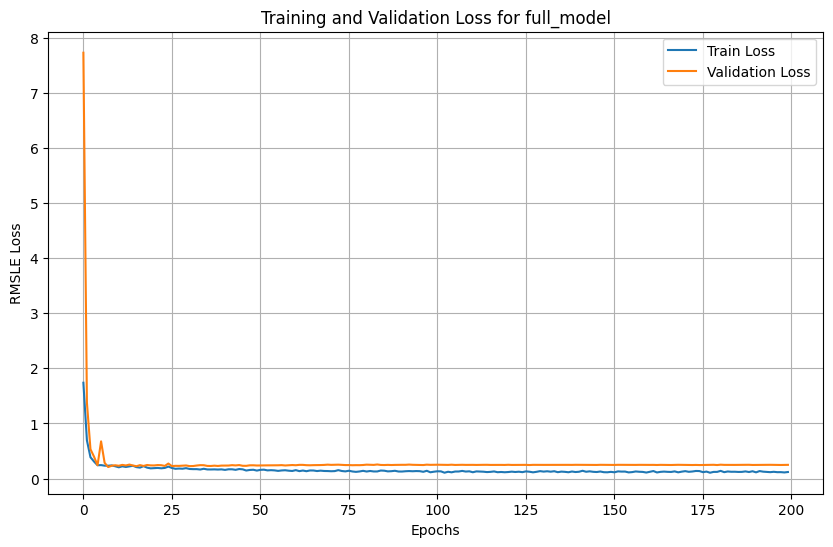

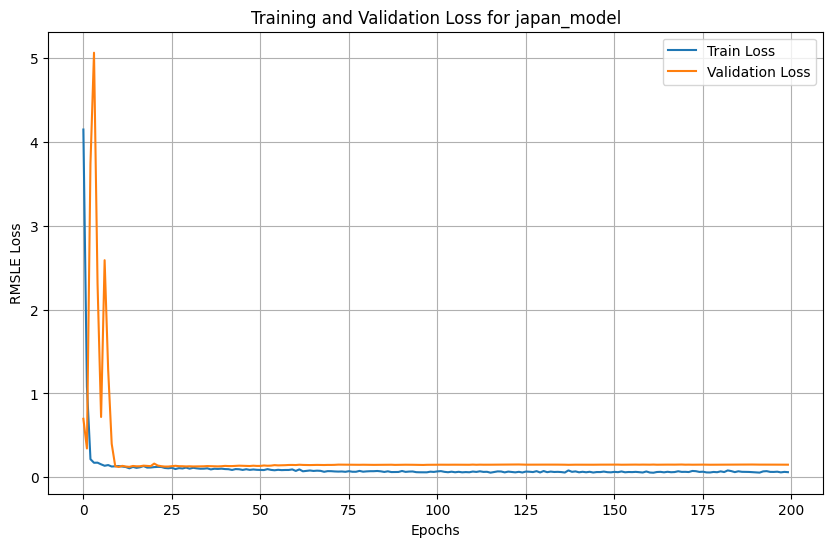

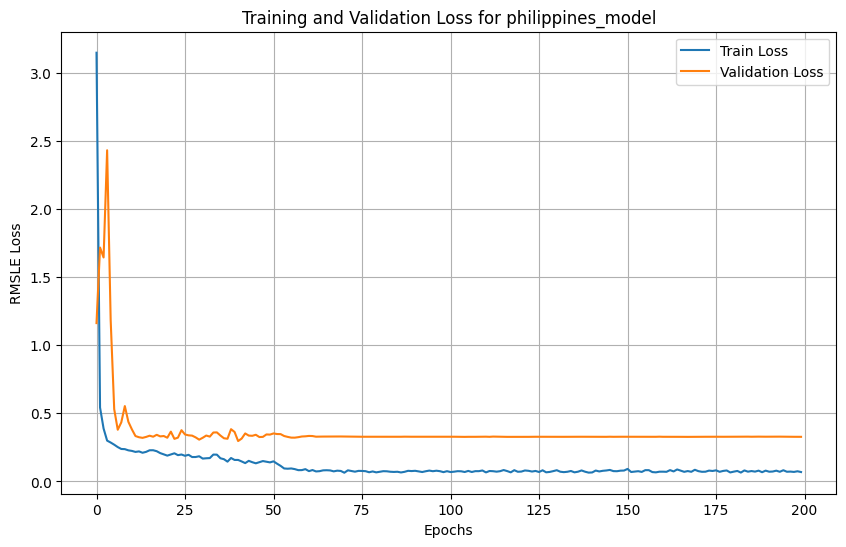

In [15]:
def plot_losses(modelName):
    checkpoint = torch.load(ModelPath / f"{modelName}.pth", weights_only=True)
    train_losses = checkpoint['train_losses']
    val_losses = checkpoint['val_losses']
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title(f'Training and Validation Loss for {modelName}')
    plt.xlabel('Epochs')
    plt.ylabel('RMSLE Loss')
    plt.legend()
    plt.grid()
    plt.show()


plot_losses("full_model")
plot_losses("japan_model")
plot_losses("philippines_model")